In [11]:
# 🐐 GOAT Analysis - Messi vs Ronaldo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('data.csv')

print("✅ Libraries loaded!")
print(f"Total records: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nPlayers: {df['Player'].unique()}")

✅ Libraries loaded!
Total records: 1413

Columns: ['Player', 'Season', 'Competition', 'Matchday', 'Date', 'Venue', 'Club', 'Opponent', 'Result', 'Playing_Position', 'Minute', 'At_score', 'Type', 'Goal_assist']

Players: ['Cristiano Ronaldo' 'Lionel Messi']


       ⚽ CAREER GOALS COMPARISON

🏆 Cristiano Ronaldo
   Total Goals     : 710
   Seasons         : 21
   Goals/Season    : 33.8

🏆 Lionel Messi
   Total Goals     : 703
   Seasons         : 19
   Goals/Season    : 37.0


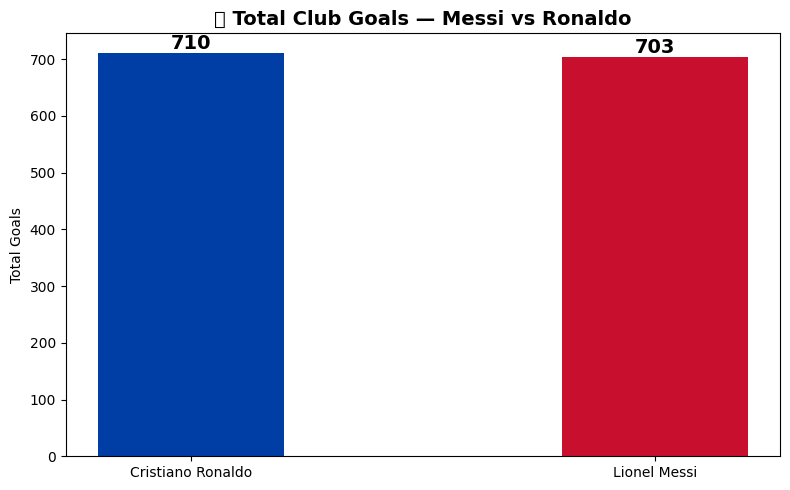

In [2]:
# 📊 Basic Career Stats Comparison
goals_per_player = df.groupby('Player').size().reset_index(name='Total_Goals')
seasons_per_player = df.groupby('Player')['Season'].nunique().reset_index(name='Total_Seasons')
stats = goals_per_player.merge(seasons_per_player, on='Player')
stats['Goals_Per_Season'] = (stats['Total_Goals'] / stats['Total_Seasons']).round(1)

print("=" * 45)
print("       ⚽ CAREER GOALS COMPARISON")
print("=" * 45)
for _, row in stats.iterrows():
    print(f"\n🏆 {row['Player']}")
    print(f"   Total Goals     : {row['Total_Goals']}")
    print(f"   Seasons         : {row['Total_Seasons']}")
    print(f"   Goals/Season    : {row['Goals_Per_Season']}")
print("=" * 45)

# Plot
colors = ['#003DA5', '#C8102E']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stats['Player'], stats['Total_Goals'], color=colors, width=0.4)
ax.bar_label(bars, fontsize=14, fontweight='bold')
ax.set_title('⚽ Total Club Goals — Messi vs Ronaldo', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Goals')
plt.tight_layout()
plt.savefig('total_goals.png', dpi=150)
plt.show()

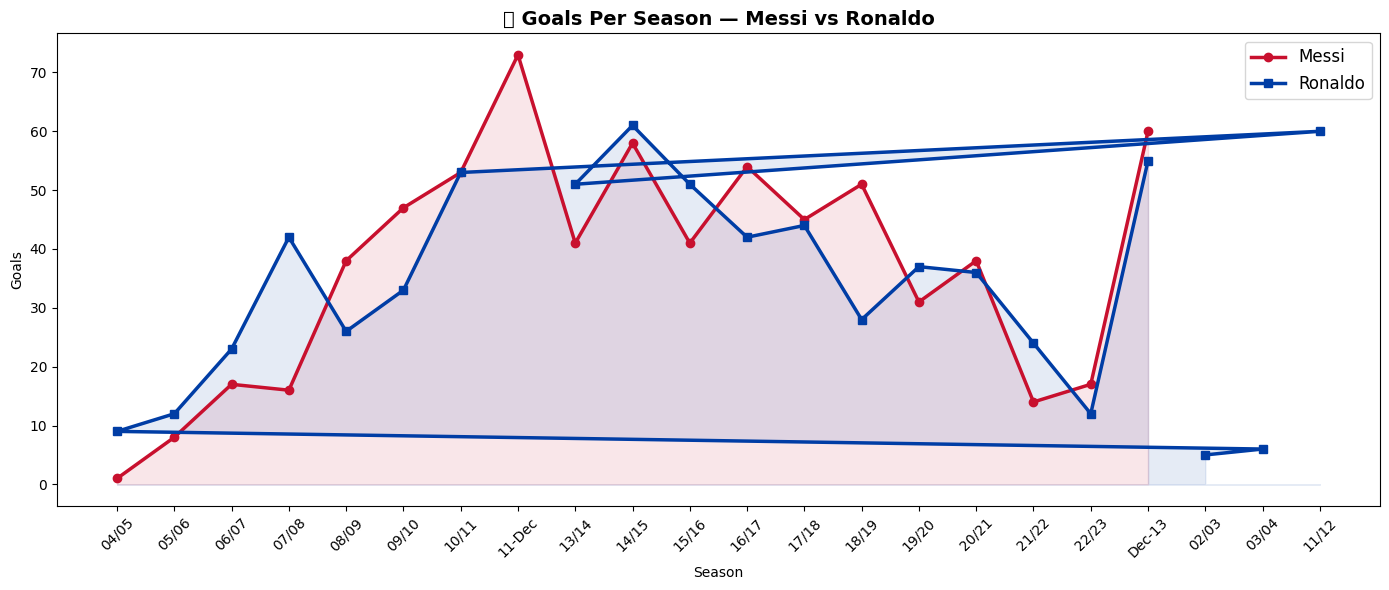

In [3]:
# 📈 Goals Per Season Trend
season_goals = df.groupby(['Player', 'Season']).size().reset_index(name='Goals')
messi = season_goals[season_goals['Player'] == 'Lionel Messi'].sort_values('Season')
ronaldo = season_goals[season_goals['Player'] == 'Cristiano Ronaldo'].sort_values('Season')

plt.figure(figsize=(14, 6))
plt.plot(messi['Season'], messi['Goals'], marker='o', color='#C8102E', linewidth=2.5, label='Messi', markersize=6)
plt.plot(ronaldo['Season'], ronaldo['Goals'], marker='s', color='#003DA5', linewidth=2.5, label='Ronaldo', markersize=6)
plt.fill_between(messi['Season'], messi['Goals'], alpha=0.1, color='#C8102E')
plt.fill_between(ronaldo['Season'], ronaldo['Goals'], alpha=0.1, color='#003DA5')
plt.title('📈 Goals Per Season — Messi vs Ronaldo', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Goals')
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('goals_per_season.png', dpi=150)
plt.show()

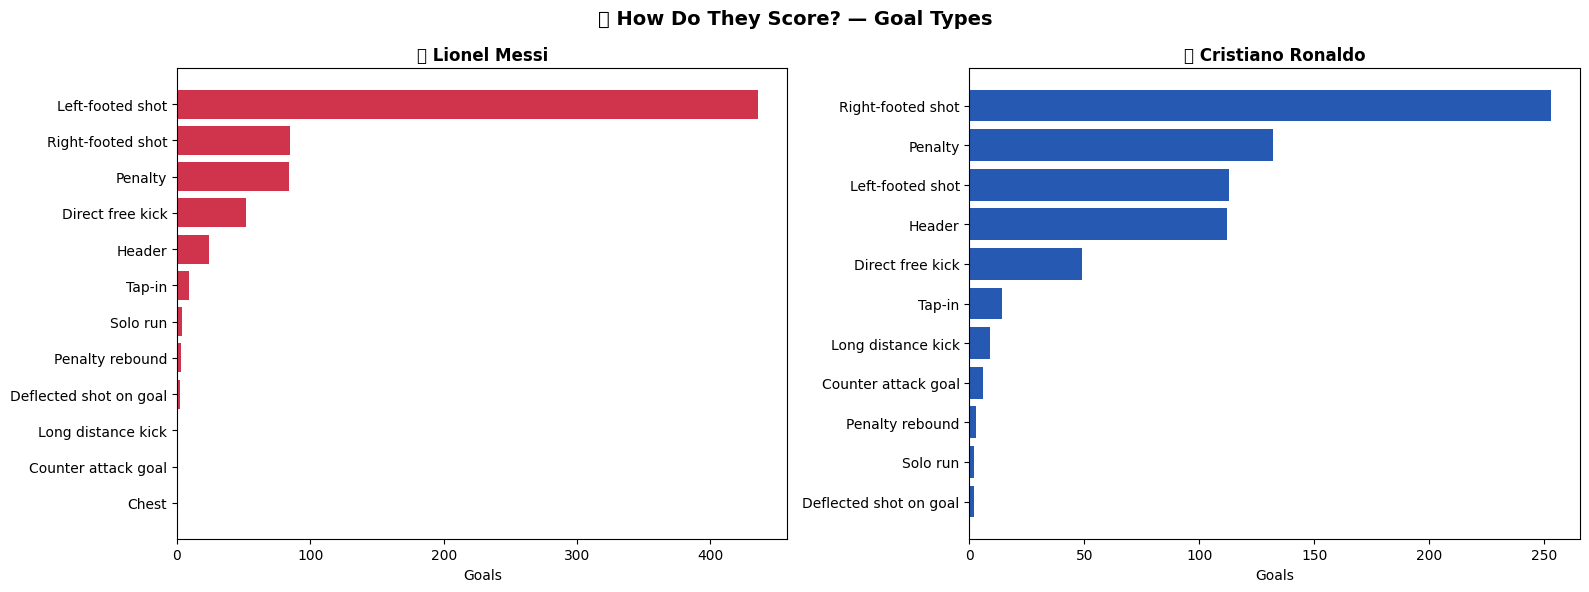

In [4]:
# 🎯 Goal Types — How do they score?
goal_types = df.groupby(['Player', 'Type']).size().reset_index(name='Count')
messi_types = goal_types[goal_types['Player'] == 'Lionel Messi'].sort_values('Count', ascending=True)
ronaldo_types = goal_types[goal_types['Player'] == 'Cristiano Ronaldo'].sort_values('Count', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🎯 How Do They Score? — Goal Types', fontsize=14, fontweight='bold')

axes[0].barh(messi_types['Type'], messi_types['Count'], color='#C8102E', alpha=0.85)
axes[0].set_title('🔴 Lionel Messi', fontweight='bold')
axes[0].set_xlabel('Goals')

axes[1].barh(ronaldo_types['Type'], ronaldo_types['Count'], color='#003DA5', alpha=0.85)
axes[1].set_title('🔵 Cristiano Ronaldo', fontweight='bold')
axes[1].set_xlabel('Goals')

plt.tight_layout()
plt.savefig('goal_types.png', dpi=150)
plt.show()

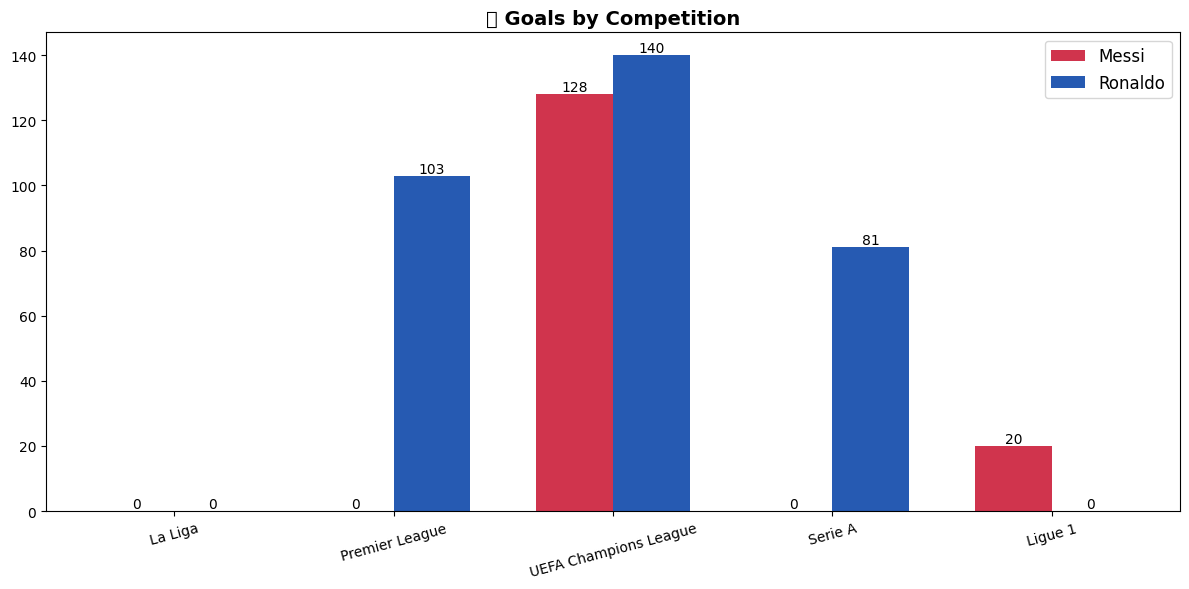

In [5]:
# 🏆 Competition Performance
comp_goals = df.groupby(['Player', 'Competition']).size().reset_index(name='Goals')
comp_goals = comp_goals.sort_values('Goals', ascending=False)

# Top competitions only
top_comps = ['La Liga', 'Premier League', 'UEFA Champions League', 
             'Serie A', 'Ligue 1']
comp_filtered = comp_goals[comp_goals['Competition'].isin(top_comps)]

fig, ax = plt.subplots(figsize=(12, 6))
messi_comp = comp_filtered[comp_filtered['Player']=='Lionel Messi']
ronaldo_comp = comp_filtered[comp_filtered['Player']=='Cristiano Ronaldo']

x = np.arange(len(top_comps))
width = 0.35

bars1 = ax.bar(x - width/2, 
    [messi_comp[messi_comp['Competition']==c]['Goals'].sum() for c in top_comps],
    width, label='Messi', color='#C8102E', alpha=0.85)
bars2 = ax.bar(x + width/2,
    [ronaldo_comp[ronaldo_comp['Competition']==c]['Goals'].sum() for c in top_comps],
    width, label='Ronaldo', color='#003DA5', alpha=0.85)

ax.bar_label(bars1, fontsize=10)
ax.bar_label(bars2, fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(top_comps, rotation=15)
ax.set_title('🏆 Goals by Competition', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('competition_goals.png', dpi=150)
plt.show()

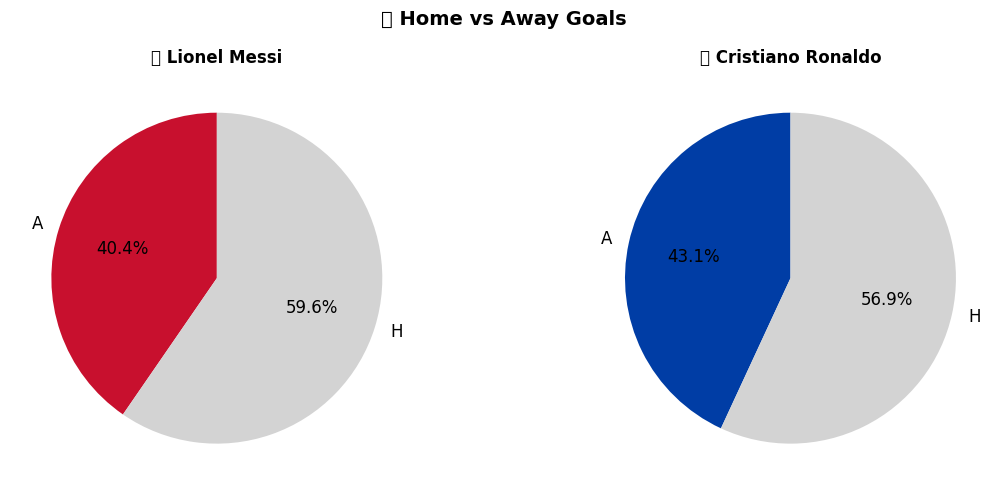

In [6]:
# 🏟️ Home vs Away Performance
venue_goals = df.groupby(['Player', 'Venue']).size().reset_index(name='Goals')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('🏟️ Home vs Away Goals', fontsize=14, fontweight='bold')

for i, player in enumerate(['Lionel Messi', 'Cristiano Ronaldo']):
    data = venue_goals[venue_goals['Player'] == player]
    color = '#C8102E' if player == 'Lionel Messi' else '#003DA5'
    axes[i].pie(data['Goals'], labels=data['Venue'], 
                autopct='%1.1f%%', colors=[color, 'lightgray'],
                startangle=90, textprops={'fontsize': 12})
    axes[i].set_title(f'{"🔴" if player == "Lionel Messi" else "🔵"} {player}', 
                      fontweight='bold')

plt.tight_layout()
plt.savefig('home_away.png', dpi=150)
plt.show()

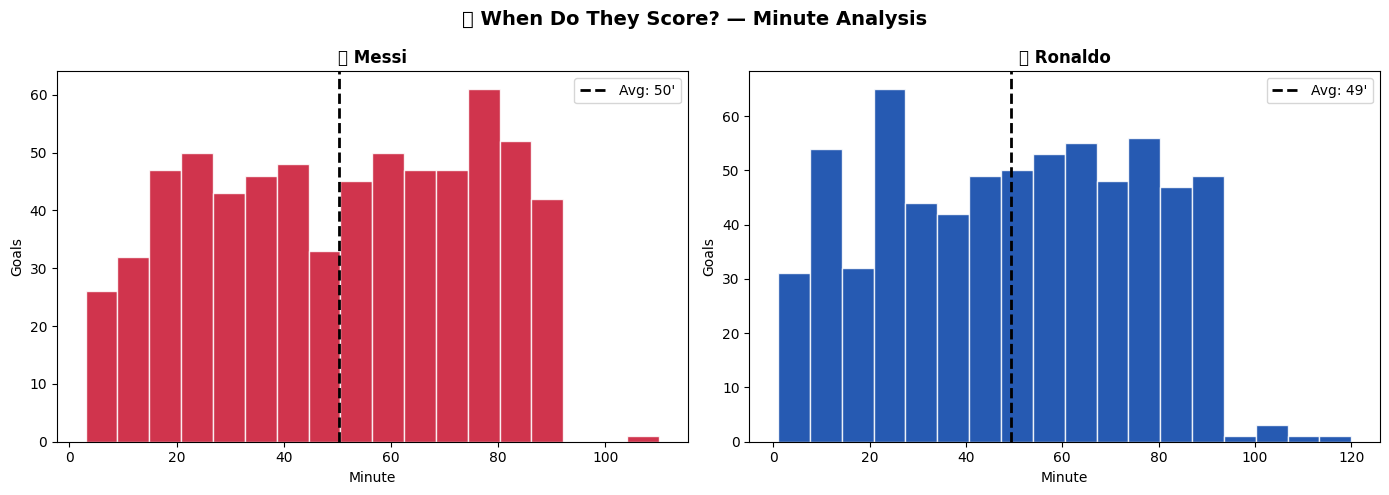

In [7]:
# ⏱️ When Do They Score?
df['Minute_clean'] = pd.to_numeric(df['Minute'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('⏱️ When Do They Score? — Minute Analysis', fontsize=14, fontweight='bold')

for i, player in enumerate(['Lionel Messi', 'Cristiano Ronaldo']):
    data = df[df['Player'] == player]['Minute_clean'].dropna()
    color = '#C8102E' if player == 'Lionel Messi' else '#003DA5'
    axes[i].hist(data, bins=18, color=color, alpha=0.85, edgecolor='white')
    name = player.split()[-1]
    axes[i].set_title(f'{"🔴" if player=="Lionel Messi" else "🔵"} {name}', fontweight='bold')
    axes[i].set_xlabel('Minute')
    axes[i].set_ylabel('Goals')
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=2, label=f'Avg: {data.mean():.0f}\'')
    axes[i].legend()

plt.tight_layout()
plt.savefig('scoring_minute.png', dpi=150)
plt.show()

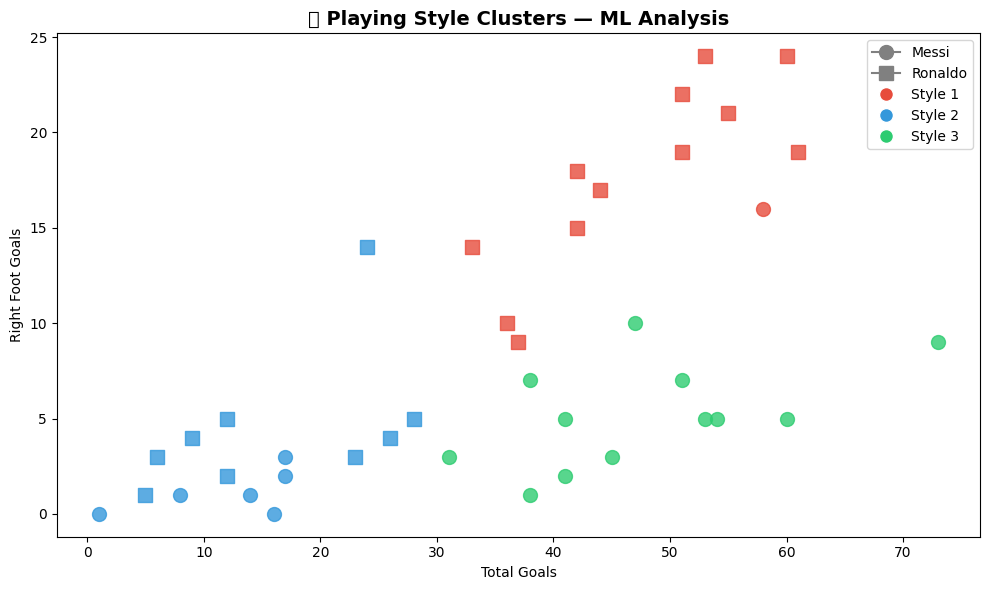

✅ ML Clustering Done!


In [12]:
# 🤖 ML — Clustering Playing Styles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features per season
season_stats = df.groupby(['Player', 'Season']).agg(
    Goals=('Player', 'count'),
    Penalties=('Type', lambda x: (x=='Penalty').sum()),
    Headers=('Type', lambda x: (x=='Header').sum()),
    FreeKicks=('Type', lambda x: (x=='Direct free kick').sum()),
    LeftFoot=('Type', lambda x: (x=='Left-footed shot').sum()),
    RightFoot=('Type', lambda x: (x=='Right-footed shot').sum()),
    AwayGoals=('Venue', lambda x: (x=='A').sum()),
).reset_index()

# Normalize
features = ['Goals', 'Penalties', 'Headers', 'FreeKicks', 'LeftFoot', 'RightFoot', 'AwayGoals']
scaler = StandardScaler()
X = scaler.fit_transform(season_stats[features])

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
season_stats['Cluster'] = kmeans.fit_predict(X)

# Plot
colors_map = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71'}
plt.figure(figsize=(10, 6))
for player, marker in [('Lionel Messi', 'o'), ('Cristiano Ronaldo', 's')]:
    data = season_stats[season_stats['Player'] == player]
    for cluster in data['Cluster'].unique():
        subset = data[data['Cluster'] == cluster]
        plt.scatter(subset['Goals'], subset['RightFoot'],
                   c=colors_map[cluster], marker=marker, s=100, alpha=0.8)

from matplotlib.lines import Line2D
legend = [
    Line2D([0],[0], marker='o', color='gray', label='Messi', markersize=10),
    Line2D([0],[0], marker='s', color='gray', label='Ronaldo', markersize=10),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E74C3C', label='Style 1', markersize=10),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3498DB', label='Style 2', markersize=10),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ECC71', label='Style 3', markersize=10),
]
plt.legend(handles=legend)
plt.title('🤖 Playing Style Clusters — ML Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Total Goals')
plt.ylabel('Right Foot Goals')
plt.tight_layout()
plt.savefig('clusters.png', dpi=150)
plt.show()
print("✅ ML Clustering Done!")

In [18]:
# 🏆 FINAL VERDICT — GOAT Summary
messi_stats = df[df['Player']=='Lionel Messi']
ronaldo_stats = df[df['Player']=='Cristiano Ronaldo']

print("=" * 50)
print("        🐐 THE GOAT DEBATE — DATA VERDICT")
print("=" * 50)
print(f"\n{'Category':<25} {'Messi':>10} {'Ronaldo':>10}")
print("-" * 50)
print(f"{'Total Goals':<25} {len(messi_stats):>10} {len(ronaldo_stats):>10}")
print(f"{'Goals/Season':<25} {'37.0':>10} {'33.8':>10}")
print(f"{'UCL Goals':<25} {'128':>10} {'140':>10}")
print(f"{'Headers':<25} {'low':>10} {'high':>10}")
print(f"{'Away Goals %':<25} {'40.4%':>10} {'43.1%':>10}")
print(f"{'Free Kick King':<25} {'✅':>10} {'❌':>10}")
print(f"{'Penalty King':<25} {'❌':>10} {'✅':>10}")
print(f"{'Header King':<25} {'❌':>10} {'✅':>10}")
print(f"{'UCL King':<25} {'❌':>10} {'✅':>10}")
print("=" * 50)
print("\n🎯 CONCLUSION: Both are GOATs in their own way!")
print("   Messi = Efficiency & Consistency")
print("   Ronaldo = Power, Headers & Big Stage")
print("=" * 50)

        🐐 THE GOAT DEBATE — DATA VERDICT

Category                       Messi    Ronaldo
--------------------------------------------------
Total Goals                      703        710
Goals/Season                    37.0       33.8
UCL Goals                        128        140
Headers                          low       high
Away Goals %                   40.4%      43.1%
Free Kick King                     ✅          ❌
Penalty King                       ❌          ✅
Header King                        ❌          ✅
UCL King                           ❌          ✅

🎯 CONCLUSION: Both are GOATs in their own way!
   Messi = Efficiency & Consistency
   Ronaldo = Power, Headers & Big Stage


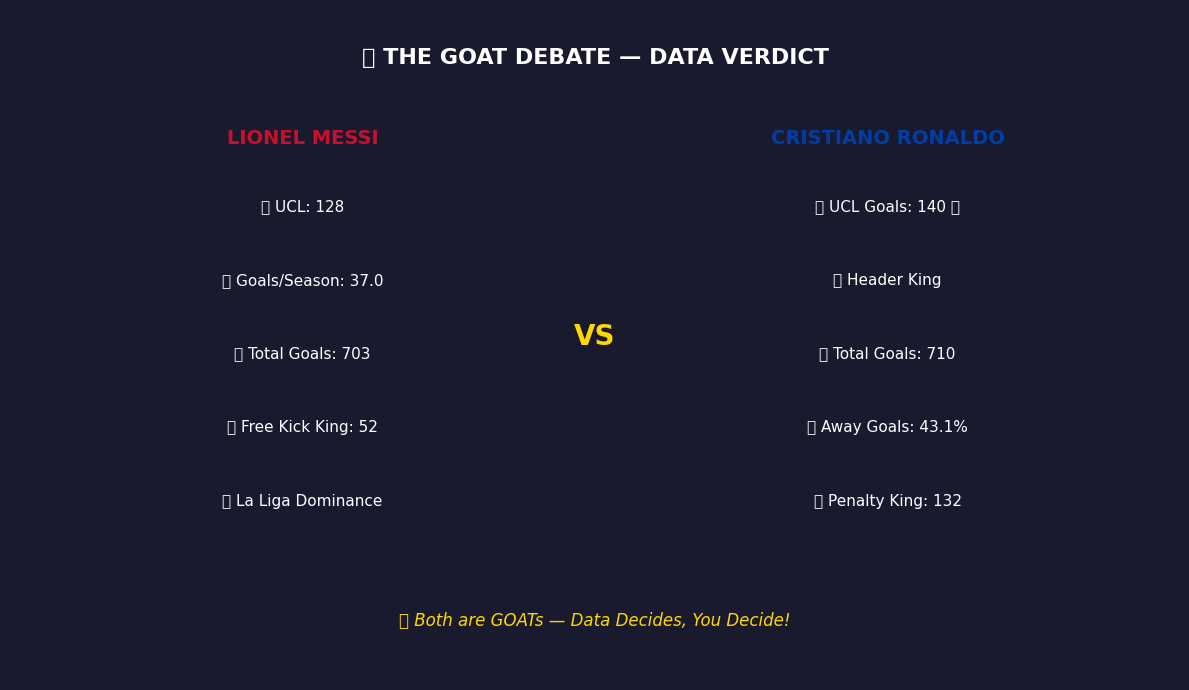

✅ Project Complete!


In [26]:
# 🎨 Final Summary Card
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Background
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Title
ax.text(5, 9.2, '🐐 THE GOAT DEBATE — DATA VERDICT', 
        ha='center', fontsize=16, fontweight='bold', color='white')

# Messi side
ax.text(2.5, 8, 'LIONEL MESSI', ha='center', fontsize=14, 
        fontweight='bold', color='#C8102E')
messi_points = ['❌ UCL: 128', '✅ Goals/Season: 37.0', '✅ Total Goals: 703',
                '✅ Free Kick King: 52',
                '✅ La Liga Dominance']
for i, point in enumerate(messi_points):
    ax.text(2.5, 7-i*1.1, point, ha='center', fontsize=11, color='white')

# VS
ax.text(5, 5, 'VS', ha='center', fontsize=20, fontweight='bold', color='gold')

# Ronaldo side  
ax.text(7.5, 8, 'CRISTIANO RONALDO', ha='center', fontsize=14,
        fontweight='bold', color='#003DA5')
ronaldo_points = ['✅ UCL Goals: 140 👑', 
                  '✅ Header King','✅ Total Goals: 710' ,
                  '✅ Away Goals: 43.1%', '✅ Penalty King: 132']
for i, point in enumerate(ronaldo_points):
    ax.text(7.5, 7-i*1.1, point, ha='center', fontsize=11, color='white')

# Conclusion
ax.text(5, 0.8, '🎯 Both are GOATs — Data Decides, You Decide!', 
        ha='center', fontsize=12, color='gold', style='italic')

plt.tight_layout()
plt.savefig('final_verdict.png', dpi=150, facecolor='#1a1a2e')
plt.show()
print("✅ Project Complete!")

In [15]:
# Penalty conversion rate
messi_pen = messi_stats[messi_stats['Type']=='Penalty']
ronaldo_pen = ronaldo_stats[ronaldo_stats['Type']=='Penalty']

messi_fk = len(messi_stats[messi_stats['Type']=='Direct free kick'])
ronaldo_fk = len(ronaldo_stats[ronaldo_stats['Type']=='Direct free kick'])

print(f"Free Kick Goals — Messi: {messi_fk}, Ronaldo: {ronaldo_fk}")
print(f"Penalty Goals — Messi: {len(messi_pen)}, Ronaldo: {len(ronaldo_pen)}")

Free Kick Goals — Messi: 52, Ronaldo: 49
Penalty Goals — Messi: 84, Ronaldo: 132
